In [1]:
# Amazon Product Reviews Analysis
import sys
sys.executable

'C:\\Program Files\\Python313\\python.exe'

In [2]:
# import the dataset
import kagglehub
path = kagglehub.dataset_download("gzdekzlkaya/amazon-product-reviews-dataset")

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import os
print(os.listdir(path))
file_path = os.path.join(path, "amazon_review.csv")
df = pd.read_csv(file_path)

['amazon_review.csv']


In [5]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [6]:
# step 1. Rename the columns acc. to you
df.rename(columns= {"overall": "Rating","helpful_yes":"Helpful"}, inplace= True)

In [7]:
# step 2. Keep only the selected column
df = df[["reviewText","summary","Rating"]]

In [8]:
# describe the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,4915.0,4.587589,0.996845,1.0,5.0,5.0,5.0,5.0


In [9]:
# Basic Preprocessing
df.isnull().sum()

reviewText    1
summary       0
Rating        0
dtype: int64

In [10]:
# handle the null value
df.dropna(subset=["reviewText"], inplace=True)

In [11]:
df.isnull().sum()

reviewText    0
summary       0
Rating        0
dtype: int64

In [12]:
# check and handle the duplicate values
df.duplicated().sum()

np.int64(0)

In [13]:
#  check the type of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4914 entries, 0 to 4914
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   reviewText  4914 non-null   object 
 1   summary     4914 non-null   object 
 2   Rating      4914 non-null   float64
dtypes: float64(1), object(2)
memory usage: 153.6+ KB


In [14]:
# step 5. Combine Text column
df["text"] = df["summary"].fillna("") + df["reviewText"]

In [15]:
# 5. Text Cleaning Function
import re
import string
import nltk
from nltk.corpus import stopwords

In [16]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
  text = text.lower()
  text = re.sub(r"<.*?>","",text) # remove html
  text = re.sub(r"http\S+", "", text) # remove url
  text = re.sub(r"[^a-zA-Z\s]","",text) # remove special character
  words = text.split()
  words = [w for w in words if w not in stop_words]
  return " ".join(words)
df["clean_text"] = df["text"].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# Encoding Target
def get_sentiment(Rating):
  if Rating >= 4:
    return "2"
  elif Rating <= 2:
    return "1"
  else:
    return "0"

df["Sentiment"] = df['Rating'].apply(get_sentiment)

In [18]:
# 6. Outliers Detection (Text Length)
df["text_length"] = df["clean_text"].apply(len)

In [19]:
# Handle the Extreme Outliers(IQR Method)
Q1 = df["text_length"].quantile(0.25)
Q3 = df["text_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[((df["text_length"] >= lower_bound) & (df["text_length"] <= upper_bound))]

In [20]:
# step 7. Remove very short reviews for removing noise fro the data
df = df[df["text_length"] > 5]


In [21]:
x_var = df["clean_text"]  # defined independent variable
y_tar = df["Sentiment"]   # defined target variable

In [22]:
# Step 9. TF-IDF Feature Creation (Term Frequency-Inverse Document Frequency)
#         Convert it into vector or the no. of time a word appear

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features= 5000)
X_tfidf = tfidf.fit_transform(x_var)

In [23]:
# we can handle it with logisticRegression class_weight= "balance"
# but I am using TF-IDF -> dense as smote for numerical data

from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components= 300)
x_reduce = svd.fit_transform(X_tfidf)

# SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state= 42)
x, y = smote.fit_resample(x_reduce,y_tar)


In [24]:
# step 10. Train-Test-split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)


In [25]:
# Step 11. Train a model

# Logistic Regression (best for NLP baseline)

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# nb = MultinomialNB()
# svm = LinearSVC()
lr = LogisticRegression(max_iter=1000, class_weight= "balanced")

# nb.fit(x_train, y_train)
# svm.fit(x_train, y_train)
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
# Step 12. Make Prediction
y_pred = lr.predict(x_test)

In [27]:
print("Train Score:", lr.score(x_train, y_train))
print("Test Score:", lr.score(x_test, y_test))

Train Score: 0.9277749874434957
Test Score: 0.9136199276817999


In [28]:
# Step 12. Evaluate model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("LR_Accuracy", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

LR_Accuracy 0.9136199276817999
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       824
           1       0.93      0.96      0.94       809
           2       0.93      0.88      0.90       856

    accuracy                           0.91      2489
   macro avg       0.91      0.91      0.91      2489
weighted avg       0.91      0.91      0.91      2489



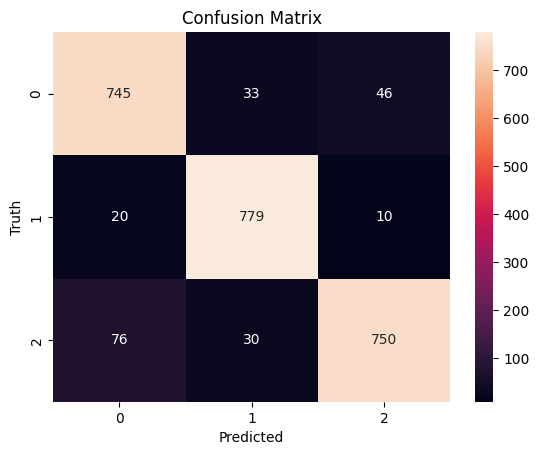

In [29]:
# step 13. Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot= True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Confusion Matrix")
plt.show()

In [30]:
# Step 14 Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param = {"C": [0.1,1,10]}
grid = GridSearchCV(LogisticRegression(max_iter =1000), param, cv=3)
grid.fit(x_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

{'C': 10}
0.9409344751448709


In [31]:
import pickle
pickle.dump(lr, open("sentiment_model.pkl","wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(svd, open("svd.pkl", "wb"))

In [34]:
def predict_sentiment_input():
    user_input = input("Enter your review: ")

    # Clean the input text using the same clean_text function
    cleaned_input = clean_text(user_input)

    review_vec = tfidf.transform([cleaned_input])  # convert to TF-IDF
    review_vec_reduced = svd.transform(review_vec) # Apply SVD to reduce dimensions
    prediction = lr.predict(review_vec_reduced)[0]

    label_map = {
        0: "negative ",
        1: "neutral ",
        2: "positive "
    }

    print("\nReview:", user_input)
    print("Predicted Sentiment:", label_map[int(prediction)])

In [35]:
predict_sentiment_input()

Enter your review:  working fine. but i don't like the product



Review: working fine. but i don't like the product
Predicted Sentiment: negative 
